In [20]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv('salaries.csv')
df.head()

,years_of_experience,salary
0,5,3150
1,9,3787
2,4,2991
3,10,4551
4,8,3540


In [32]:
x=df.iloc[:,:-1].values
x[0:5]


array([[ 5],
       [ 9],
       [ 4],
       [10],
       [ 8]])

In [33]:
y=df.iloc[:,-1].values
y[0:5]

array([3150, 3787, 2991, 4551, 3540])

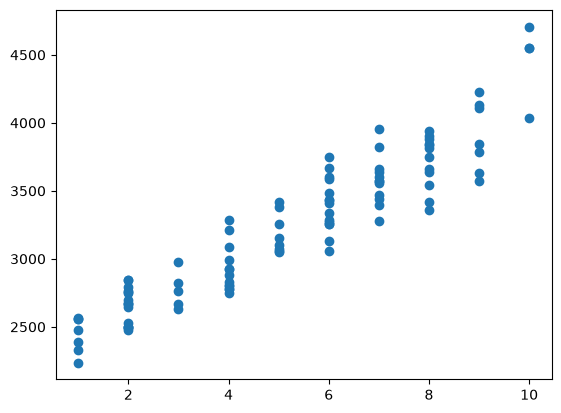

In [34]:
plt.scatter(x,y)

In [52]:
from sklearn.model_selection import train_test_split
x_train,x_test, y_train,y_test = train_test_split(x,y , test_size=0.2 , random_state=0)
x_test.shape

(20, 1)

In [48]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [53]:
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[192.66]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2238
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[23.71]


In [54]:
model.predict([[7], [5] ,[3.5]])

array([3587.02214514, 3201.70090715, 2912.70997866])

In [55]:
y_pred =model.predict(x_test)
y_pred

array([2816.37966916, 3779.68276414, 3009.04028815, 3779.68276414,
       3587.02214514, 2623.71905016, 4165.00400213, 3201.70090715,
       3587.02214514, 3009.04028815, 2431.05843116, 3587.02214514,
       3201.70090715, 3587.02214514, 3394.36152615, 3587.02214514,
       3779.68276414, 2623.71905016, 3201.70090715, 2816.37966916])

In [56]:
error =y_pred -y_test
error

array([ 147.37966916,  118.68276414,   18.04028815,   28.68276414,
         12.02214514,  -48.28094984, -542.99599787,  131.70090715,
        -11.97785486,  125.04028815,   42.05843116,  190.02214514,
        141.70090715,  306.02214514,  125.36152615,  -50.97785486,
        141.68276414,  -74.28094984,  102.70090715,   49.37966916])

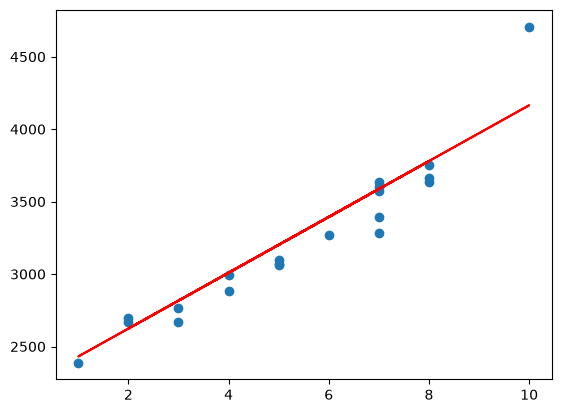

In [59]:
plt.scatter(x_test,y_test)
plt.plot(x_test , y_pred, color='red')

In [60]:
from sklearn.metrics import r2_score
r2 =r2_score(y_test ,y_pred)
r2

0.8921287198195745